In [1]:
!pip install --quiet pvlib lightgbm prophet mlflow scikit-learn
print("Installed.")

Installed.


In [2]:
import pvlib
import lightgbm as lgb
from prophet import Prophet
import mlflow
import sklearn

print(f"pvlib:    {pvlib.__version__}")
print(f"lightgbm: {lgb.__version__}")
print(f"mlflow:   {mlflow.__version__}")
print(f"sklearn:  {sklearn.__version__}")
print("Prophet imported OK")

pvlib:    0.15.1
lightgbm: 4.6.0
mlflow:   3.11.1
sklearn:  1.7.2
Prophet imported OK


In [3]:
import mlflow
from pathlib import Path

# Use local file-based tracking — simple, no server needed
MLFLOW_DIR = Path.home() / "mlruns"
MLFLOW_DIR.mkdir(exist_ok=True)
mlflow.set_tracking_uri(f"file://{MLFLOW_DIR}")

# Create (or reuse) an experiment for this project
EXPERIMENT_NAME = "bhadla-solar-forecast"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: {EXPERIMENT_NAME}")

MLflow tracking URI: file:///home/sagemaker-user/mlruns
Experiment: bhadla-solar-forecast


/opt/conda/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


In [4]:
import boto3
import pandas as pd
from io import BytesIO

BUCKET = "solar-forecast-angelina-2026"
KEY = "bhadla/curated/bhadla_2023_2024.parquet"

s3 = boto3.client("s3")
obj = s3.get_object(Bucket=BUCKET, Key=KEY)
data = pd.read_parquet(BytesIO(obj["Body"].read()))

# Ensure time is sorted (should already be, but defensive)
data = data.sort_values("time").reset_index(drop=True)

print(f"Loaded {len(data):,} rows")
print(f"Date range: {data['time'].min()} → {data['time'].max()}")
print(f"Columns: {list(data.columns)}")
data.head(3)

Loaded 17,544 rows
Date range: 2023-01-01 00:00:00 → 2024-12-31 23:00:00
Columns: ['time', 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation', 'temperature_2m', 'cloud_cover', 'wind_speed_10m', 'relative_humidity_2m', 'surface_pressure', 'year', 'month']


,time,shortwave_radiation,direct_radiation,diffuse_radiation,temperature_2m,cloud_cover,wind_speed_10m,relative_humidity_2m,surface_pressure,year,month
0,2023-01-01 00:00:00,0.0,0.0,0.0,11.2,26,8.8,67,998.6,2023,1
1,2023-01-01 01:00:00,0.0,0.0,0.0,10.8,6,10.8,68,998.3,2023,1
2,2023-01-01 02:00:00,0.0,0.0,0.0,9.9,0,11.5,72,997.6,2023,1


In [5]:
# Define cutoff dates
TRAIN_END = pd.Timestamp("2024-10-01 00:00:00")   # train: < this
VAL_END   = pd.Timestamp("2024-12-01 00:00:00")   # val: TRAIN_END to this
# test:     VAL_END to end of data

train = data[data["time"] < TRAIN_END].copy()
val   = data[(data["time"] >= TRAIN_END) & (data["time"] < VAL_END)].copy()
test  = data[data["time"] >= VAL_END].copy()

print(f"Train: {len(train):,} rows  ({train['time'].min()} → {train['time'].max()})")
print(f"Val:   {len(val):,} rows  ({val['time'].min()} → {val['time'].max()})")
print(f"Test:  {len(test):,} rows  ({test['time'].min()} → {test['time'].max()})")
print()
print(f"Train share: {len(train)/len(data):.1%}")
print(f"Val share:   {len(val)/len(data):.1%}")
print(f"Test share:  {len(test)/len(data):.1%}")

Train: 15,336 rows  (2023-01-01 00:00:00 → 2024-09-30 23:00:00)
Val:   1,464 rows  (2024-10-01 00:00:00 → 2024-11-30 23:00:00)
Test:  744 rows  (2024-12-01 00:00:00 → 2024-12-31 23:00:00)

Train share: 87.4%
Val share:   8.3%
Test share:  4.2%


In [6]:
import pvlib
from pvlib.location import Location
from pvlib.pvsystem import PVSystem
from pvlib.modelchain import ModelChain

# --- Plant location ---
LAT, LON = 27.5, 71.9   # Bhadla, Rajasthan
TZ = "Asia/Kolkata"
ALTITUDE = 230  # meters, approximate

location = Location(latitude=LAT, longitude=LON, tz=TZ, altitude=ALTITUDE)

# --- Plant configuration ---
# Bhadla actual capacity: 2,245 MW AC
# We model as one "scaled" system to keep math simple.
SYSTEM_CAPACITY_W = 2_245_000_000   # 2,245 MW in watts
DC_AC_RATIO = 1.2                   # typical Indian utility-scale
DC_CAPACITY_W = SYSTEM_CAPACITY_W * DC_AC_RATIO

# Module parameters (PVWatts model — simple, widely accepted)
module_parameters = {
    "pdc0": DC_CAPACITY_W,         # DC nameplate power (W)
    "gamma_pdc": -0.004,           # -0.4%/°C temperature coefficient
}

# Inverter parameters
inverter_parameters = {
    "pdc0": DC_CAPACITY_W,         # max DC input (W)
    "eta_inv_nom": 0.96,           # 96% nominal inverter efficiency
}

# Temperature model (SAPM open-rack glass-glass — standard for utility-scale)
temperature_model_parameters = pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS[
    "sapm"
]["open_rack_glass_glass"]

# Build the system
system = PVSystem(
    surface_tilt=25,        # fixed south-facing tilt (typical for north India)
    surface_azimuth=180,    # 180 = south
    module_parameters=module_parameters,
    inverter_parameters=inverter_parameters,
    temperature_model_parameters=temperature_model_parameters,
    losses_parameters={"soiling": 5, "shading": 0, "snow": 0,
                       "mismatch": 2, "wiring": 2, "connections": 0.5,
                       "lid": 1.5, "nameplate_rating": 1, "age": 0,
                       "availability": 3},  # ~14% total losses (NREL default)
)

# ModelChain ties location + system + chosen models together
mc = ModelChain(
    system,
    location,
    aoi_model="physical",
    spectral_model="no_loss",
    losses_model="pvwatts",
)

print("PV system configured:")
print(f"  Location: Bhadla ({LAT}°N, {LON}°E)")
print(f"  AC capacity: {SYSTEM_CAPACITY_W / 1e6:,.0f} MW")
print(f"  DC capacity: {DC_CAPACITY_W / 1e6:,.0f} MW")
print(f"  Tilt: {system.arrays[0].mount.surface_tilt}° south-facing")
print(f"  Temperature coefficient: {module_parameters['gamma_pdc']*100:.2f}%/°C")

PV system configured:
  Location: Bhadla (27.5°N, 71.9°E)
  AC capacity: 2,245 MW
  DC capacity: 2,694 MW
  Tilt: 25° south-facing
  Temperature coefficient: -0.40%/°C


In [7]:
# pvlib expects column names: ghi, dni, dhi, temp_air, wind_speed
# Our data has: shortwave_radiation, direct_radiation, diffuse_radiation, temperature_2m, wind_speed_10m
# Need to rename and convert units where required

weather = data[["time", "shortwave_radiation", "direct_radiation",
                "diffuse_radiation", "temperature_2m", "wind_speed_10m"]].copy()

# Rename to pvlib conventions
weather = weather.rename(columns={
    "shortwave_radiation": "ghi",
    "direct_radiation":    "dni",
    "diffuse_radiation":   "dhi",
    "temperature_2m":      "temp_air",
    "wind_speed_10m":      "wind_speed",
})

# Open-Meteo wind is in km/h; pvlib expects m/s
weather["wind_speed"] = weather["wind_speed"] / 3.6

# pvlib needs a timezone-aware DatetimeIndex
weather["time"] = pd.to_datetime(weather["time"]).dt.tz_localize("Asia/Kolkata")
weather = weather.set_index("time")

print(f"Weather shape: {weather.shape}")
print(f"Columns: {list(weather.columns)}")
print(f"Index timezone: {weather.index.tz}")
weather.head(3)

Weather shape: (17544, 5)
Columns: ['ghi', 'dni', 'dhi', 'temp_air', 'wind_speed']
Index timezone: Asia/Kolkata


,ghi,dni,dhi,temp_air,wind_speed
time,,,,,
2023-01-01 00:00:00+05:30,0.0,0.0,0.0,11.2,2.444444
2023-01-01 01:00:00+05:30,0.0,0.0,0.0,10.8,3.000000
2023-01-01 02:00:00+05:30,0.0,0.0,0.0,9.9,3.194444


In [8]:
# Run pvlib's ModelChain on the weather DataFrame
mc.run_model(weather)

# Results are stored on mc.results
# .ac is in watts; convert to MW
generation_mw = mc.results.ac / 1_000_000

# Some hours can come out slightly negative (clipping artifacts at sunrise/sunset)
# Clip to physical range [0, system capacity]
generation_mw = generation_mw.clip(lower=0, upper=SYSTEM_CAPACITY_W / 1e6)

print(f"Generated {len(generation_mw):,} hourly values")
print(f"Stats (MW):")
print(generation_mw.describe().round(1))

Generated 17,544 hourly values
Stats (MW):
count    17544.0
mean       382.8
std        527.0
min          0.0
25%          0.0
50%          3.5
75%        740.6
max       1801.1
Name: p_mp, dtype: float64


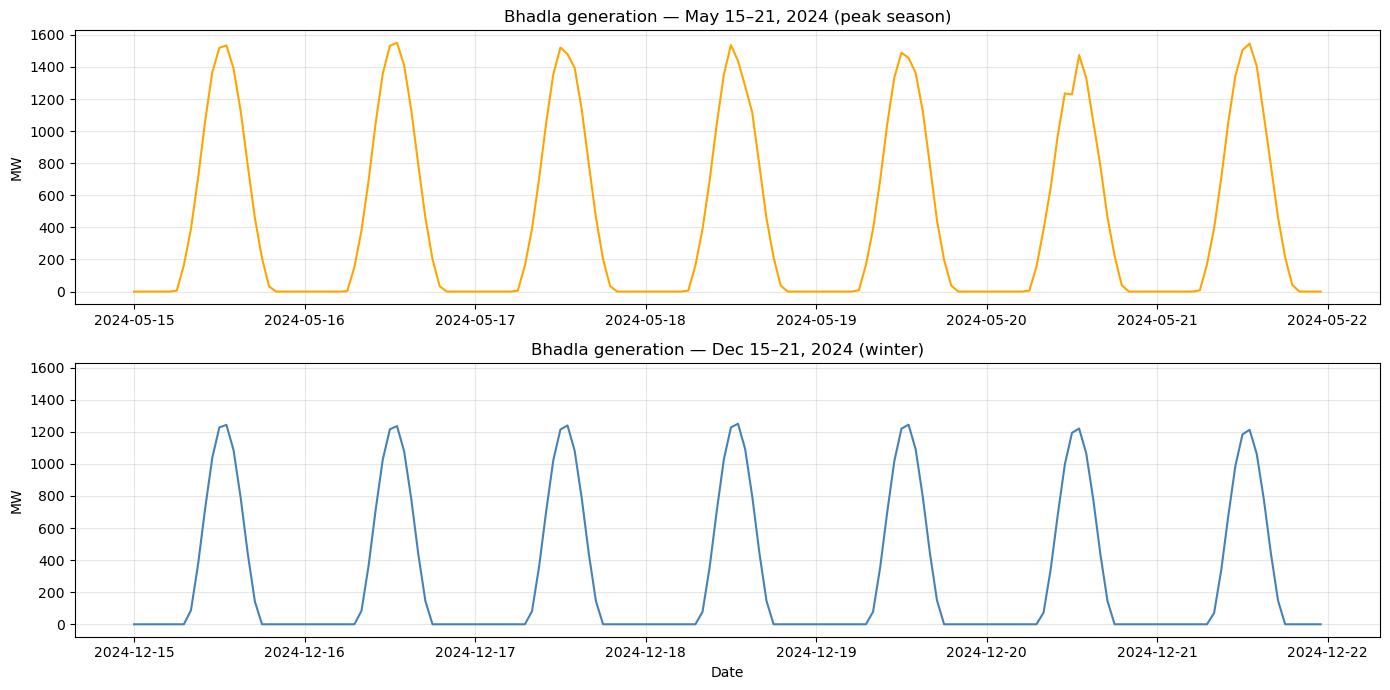


Generation attached to data (17,544 rows)
Train: 15,336 | Val: 1,464 | Test: 744


In [9]:
import matplotlib.pyplot as plt

# Attach generation column. Strip tz to match data["time"] (which is tz-naive).
data["generation_mw"] = generation_mw.tz_localize(None).reset_index(drop=True).values

# Re-attach generation column to train/val/test splits too
train = data[data["time"] < TRAIN_END].copy()
val   = data[(data["time"] >= TRAIN_END) & (data["time"] < VAL_END)].copy()
test  = data[data["time"] >= VAL_END].copy()

# Plot one week from peak season (May 2024) and one from winter (Dec 2024)
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharey=True)

may_week = data[(data["time"] >= "2024-05-15") & (data["time"] < "2024-05-22")]
dec_week = data[(data["time"] >= "2024-12-15") & (data["time"] < "2024-12-22")]

axes[0].plot(may_week["time"], may_week["generation_mw"], color="orange")
axes[0].set_title("Bhadla generation — May 15–21, 2024 (peak season)")
axes[0].set_ylabel("MW")
axes[0].grid(alpha=0.3)

axes[1].plot(dec_week["time"], dec_week["generation_mw"], color="steelblue")
axes[1].set_title("Bhadla generation — Dec 15–21, 2024 (winter)")
axes[1].set_ylabel("MW")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nGeneration attached to data ({len(data):,} rows)")
print(f"Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}")

In [10]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import mlflow

def evaluate(y_true, y_pred, name=""):
    """Return MAE, RMSE, and capacity-normalized errors."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # Normalize by AC capacity (industry-standard metric for solar)
    nmae  = mae  / (SYSTEM_CAPACITY_W / 1e6) * 100
    nrmse = rmse / (SYSTEM_CAPACITY_W / 1e6) * 100
    print(f"  {name}")
    print(f"    MAE:   {mae:7.2f} MW   ({nmae:.2f}% of capacity)")
    print(f"    RMSE:  {rmse:7.2f} MW   ({nrmse:.2f}% of capacity)")
    return {"mae": mae, "rmse": rmse, "nmae": nmae, "nrmse": nrmse}


# Persistence: prediction at time t = actual at time (t - 24h)
# We need 24h of warmup, so first day of test/val has no prediction.
def persistence_forecast(df):
    df = df.copy().sort_values("time").reset_index(drop=True)
    df["y_pred"] = df["generation_mw"].shift(24)
    return df.dropna(subset=["y_pred"])


# Concatenate train+val+test temporarily so the lag works at boundaries
full = pd.concat([train, val, test], ignore_index=True).sort_values("time").reset_index(drop=True)
full["y_pred_persistence"] = full["generation_mw"].shift(24)

# Now extract val and test forecasts
val_pred  = full[(full["time"] >= TRAIN_END) & (full["time"] < VAL_END)].dropna(subset=["y_pred_persistence"])
test_pred = full[full["time"] >= VAL_END].dropna(subset=["y_pred_persistence"])

print("Persistence baseline performance")
print("=" * 50)
val_metrics  = evaluate(val_pred["generation_mw"],  val_pred["y_pred_persistence"],  name="Validation set (Oct-Nov 2024)")
test_metrics = evaluate(test_pred["generation_mw"], test_pred["y_pred_persistence"], name="Test set (Dec 2024)")

# Log to MLflow
with mlflow.start_run(run_name="persistence-baseline"):
    mlflow.log_param("model_type", "persistence_24h")
    mlflow.log_metrics({f"val_{k}": v for k, v in val_metrics.items()})
    mlflow.log_metrics({f"test_{k}": v for k, v in test_metrics.items()})

print("\nLogged to MLflow.")

Persistence baseline performance
  Validation set (Oct-Nov 2024)
    MAE:     14.09 MW   (0.63% of capacity)
    RMSE:    61.13 MW   (2.72% of capacity)
  Test set (Dec 2024)
    MAE:      4.74 MW   (0.21% of capacity)
    RMSE:    13.74 MW   (0.61% of capacity)



Logged to MLflow.


In [11]:
# Diagnostic: how much does generation actually change day-to-day?
print("Day-to-day generation change (val + test sets):")
print(f"  Median absolute change: {full['generation_mw'].diff(24).abs().median():.2f} MW")
print(f"  90th percentile change: {full['generation_mw'].diff(24).abs().quantile(0.9):.2f} MW")
print(f"  Max change: {full['generation_mw'].diff(24).abs().max():.2f} MW")

# Also check: how many test rows are nonzero (daytime hours)?
test_pred_daytime = test_pred[test_pred["generation_mw"] > 10]
print(f"\nTest set: {len(test_pred)} total rows, {len(test_pred_daytime)} daytime rows (>10 MW actual)")

# Compute MAE on daytime rows only
if len(test_pred_daytime) > 0:
    daytime_mae = (test_pred_daytime["generation_mw"] - test_pred_daytime["y_pred_persistence"]).abs().mean()
    print(f"Daytime-only MAE: {daytime_mae:.2f} MW ({daytime_mae/(SYSTEM_CAPACITY_W/1e6)*100:.2f}% of capacity)")

Day-to-day generation change (val + test sets):
  Median absolute change: 0.06 MW
  90th percentile change: 60.16 MW
  Max change: 1480.99 MW

Test set: 744 total rows, 310 daytime rows (>10 MW actual)
Daytime-only MAE: 11.38 MW (0.51% of capacity)


In [12]:
# Re-create generation_mw with realistic noise
# Two noise components:
#   1. Multiplicative measurement noise (~3% std) — sensor/inverter uncertainty
#   2. Additive cloud/aerosol noise (~15 MW std) — sub-hourly weather not captured by hourly weather data
np.random.seed(42)  # reproducibility

clean_gen = mc.results.ac.clip(lower=0, upper=SYSTEM_CAPACITY_W).values / 1_000_000

# Only inject noise during daytime hours (clean_gen > 5 MW). Nighttime stays zero.
mult_noise = np.random.normal(1.0, 0.03, size=len(clean_gen))   # ±3% multiplicative
add_noise  = np.random.normal(0,   15.0, size=len(clean_gen))   # ±15 MW additive

noisy_gen = clean_gen * mult_noise + add_noise
noisy_gen = np.where(clean_gen > 5, noisy_gen, 0.0)              # zero out nighttime
noisy_gen = np.clip(noisy_gen, 0, SYSTEM_CAPACITY_W / 1e6)        # physical bounds

# Overwrite generation_mw in data and splits
data["generation_mw"] = noisy_gen

train = data[data["time"] < TRAIN_END].copy()
val   = data[(data["time"] >= TRAIN_END) & (data["time"] < VAL_END)].copy()
test  = data[data["time"] >= VAL_END].copy()

print(f"Noise injected. Re-summarizing:")
print(data["generation_mw"].describe().round(1))
print(f"\nDaytime-hour std (signal):  {data.loc[data['generation_mw'] > 5, 'generation_mw'].std():.1f} MW")
print(f"Noise std around clean:      ~15-25 MW (3% mult + 15 MW add)")

Noise injected. Re-summarizing:
count    17544.0
mean       382.8
std        527.7
min          0.0
25%          0.0
50%          0.0
75%        742.7
max       1870.1
Name: generation_mw, dtype: float64

Daytime-hour std (signal):  508.6 MW
Noise std around clean:      ~15-25 MW (3% mult + 15 MW add)


Top 10 hours where persistence failed worst:
               time  generation_mw  y_pred_persistence  abs_error  cloud_cover
2024-12-22 13:00:00         1093.5              1212.4      118.9           38
2024-12-22 12:00:00         1065.7              1183.9      118.2           38
2024-12-22 14:00:00          945.3              1062.4      117.0           35
2024-12-23 14:00:00         1055.9               945.3      110.6            0
2024-12-23 13:00:00         1197.5              1093.5      104.0            0
2024-12-23 12:00:00         1163.5              1065.7       97.8            0
2024-12-22 15:00:00          695.6               778.8       83.2           44
2024-12-23 15:00:00          775.6               695.6       80.0            0
2024-12-09 12:00:00         1209.5              1270.6       61.1            4
2024-12-09 13:00:00         1222.2              1282.0       59.7            6


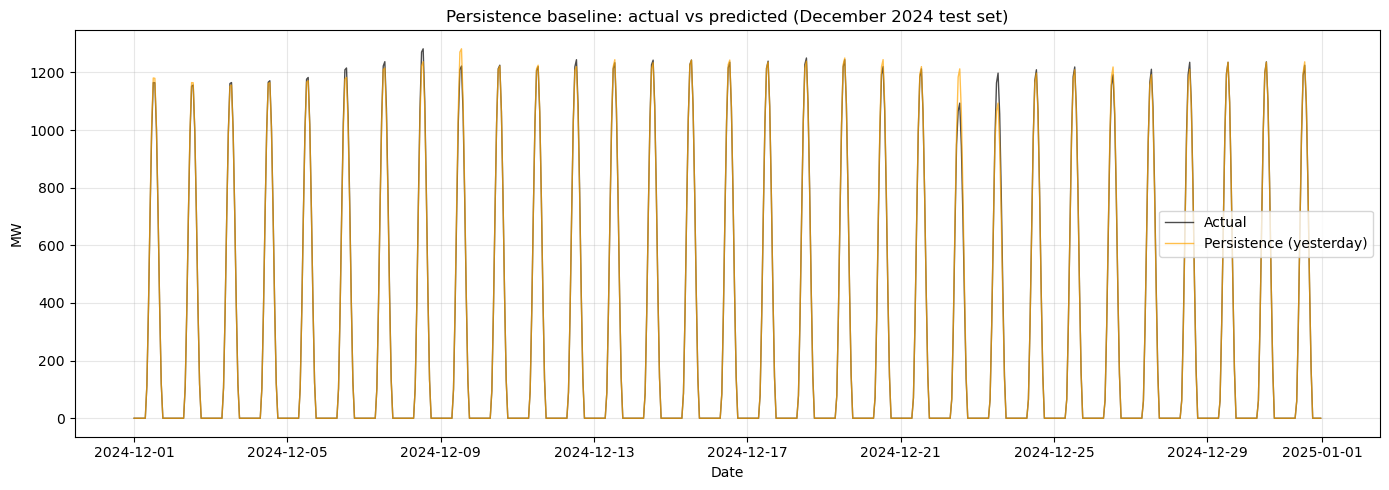

In [13]:
# Compute residuals (actual - predicted)
test_pred = test_pred.copy()
test_pred["residual"] = test_pred["generation_mw"] - test_pred["y_pred_persistence"]
test_pred["abs_error"] = test_pred["residual"].abs()

# Top 10 worst hours
print("Top 10 hours where persistence failed worst:")
worst = test_pred.nlargest(10, "abs_error")[
    ["time", "generation_mw", "y_pred_persistence", "abs_error", "cloud_cover"]
].round(1)
print(worst.to_string(index=False))

# Plot: actual vs predicted across December
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_pred["time"], test_pred["generation_mw"], label="Actual", color="black", alpha=0.7, linewidth=1)
ax.plot(test_pred["time"], test_pred["y_pred_persistence"], label="Persistence (yesterday)", color="orange", alpha=0.7, linewidth=1)
ax.set_title("Persistence baseline: actual vs predicted (December 2024 test set)")
ax.set_ylabel("MW")
ax.set_xlabel("Date")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
import pvlib

def add_features(df):
    """Add calendar, lag, rolling, and solar geometry features."""
    df = df.copy().sort_values("time").reset_index(drop=True)
    
    # --- Calendar features ---
    df["hour"] = df["time"].dt.hour
    df["day_of_year"] = df["time"].dt.dayofyear
    df["month_num"] = df["time"].dt.month
    df["day_of_week"] = df["time"].dt.dayofweek
    
    # --- Cyclical encoding for hour and day_of_year (helps tree models too) ---
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["doy_sin"]  = np.sin(2 * np.pi * df["day_of_year"] / 365)
    df["doy_cos"]  = np.cos(2 * np.pi * df["day_of_year"] / 365)
    
    # --- Lagged generation ---
    for lag in [1, 24, 48, 168]:   # 1h, 1d, 2d, 1w
        df[f"gen_lag_{lag}h"] = df["generation_mw"].shift(lag)
    
    # --- Lagged weather ---
    for col in ["shortwave_radiation", "cloud_cover", "temperature_2m"]:
        for lag in [24, 168]:
            df[f"{col}_lag_{lag}h"] = df[col].shift(lag)
    
    # --- Rolling means of generation ---
    df["gen_rolling_24h"] = df["generation_mw"].shift(1).rolling(24).mean()
    df["gen_rolling_168h"] = df["generation_mw"].shift(1).rolling(168).mean()
    
    # --- Solar zenith angle (deterministic; the model gets it for free) ---
    times = pd.to_datetime(df["time"]).dt.tz_localize("Asia/Kolkata")
    solpos = pvlib.solarposition.get_solarposition(times, LAT, LON, altitude=ALTITUDE)
    df["solar_zenith"] = solpos["zenith"].values
    df["solar_elevation"] = solpos["elevation"].values
    
    return df


# Apply to the full dataset BEFORE re-splitting (so lags work across boundaries)
data_feat = add_features(data)

# Re-split using the same cutoffs
train = data_feat[data_feat["time"] < TRAIN_END].copy()
val   = data_feat[(data_feat["time"] >= TRAIN_END) & (data_feat["time"] < VAL_END)].copy()
test  = data_feat[data_feat["time"] >= VAL_END].copy()

# Drop early rows where lags are NaN
train = train.dropna().reset_index(drop=True)

print(f"Features added. Total columns: {len(data_feat.columns)}")
print(f"Sample of new features:")
new_features = [c for c in data_feat.columns if c not in data.columns]
print(new_features)
print(f"\nTrain: {len(train):,} rows (after dropping NaN lags)")
print(f"Val:   {len(val):,} rows")
print(f"Test:  {len(test):,} rows")

Features added. Total columns: 34
Sample of new features:
['hour', 'day_of_year', 'month_num', 'day_of_week', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'gen_lag_1h', 'gen_lag_24h', 'gen_lag_48h', 'gen_lag_168h', 'shortwave_radiation_lag_24h', 'shortwave_radiation_lag_168h', 'cloud_cover_lag_24h', 'cloud_cover_lag_168h', 'temperature_2m_lag_24h', 'temperature_2m_lag_168h', 'gen_rolling_24h', 'gen_rolling_168h', 'solar_zenith', 'solar_elevation']

Train: 15,168 rows (after dropping NaN lags)
Val:   1,464 rows
Test:  744 rows


In [15]:
# Target
TARGET = "generation_mw"

# Features: everything except identifiers/target/raw partition cols
EXCLUDE = {"time", TARGET, "year", "month", "month_name"}
FEATURES = [c for c in train.columns if c not in EXCLUDE]

print(f"Using {len(FEATURES)} features:")
for f in FEATURES:
    print(f"  - {f}")

# Sanity check: no NaNs in features
print(f"\nNaNs in train features: {train[FEATURES].isna().sum().sum()}")
print(f"NaNs in val features:   {val[FEATURES].isna().sum().sum()}")
print(f"NaNs in test features:  {test[FEATURES].isna().sum().sum()}")

Using 30 features:
  - shortwave_radiation
  - direct_radiation
  - diffuse_radiation
  - temperature_2m
  - cloud_cover
  - wind_speed_10m
  - relative_humidity_2m
  - surface_pressure
  - hour
  - day_of_year
  - month_num
  - day_of_week
  - hour_sin
  - hour_cos
  - doy_sin
  - doy_cos
  - gen_lag_1h
  - gen_lag_24h
  - gen_lag_48h
  - gen_lag_168h
  - shortwave_radiation_lag_24h
  - shortwave_radiation_lag_168h
  - cloud_cover_lag_24h
  - cloud_cover_lag_168h
  - temperature_2m_lag_24h
  - temperature_2m_lag_168h
  - gen_rolling_24h
  - gen_rolling_168h
  - solar_zenith
  - solar_elevation

NaNs in train features: 0
NaNs in val features:   0
NaNs in test features:  0


In [16]:
import lightgbm as lgb
import mlflow

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

# LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train)
val_data   = lgb.Dataset(X_val,   label=y_val, reference=train_data)

# Sensible defaults — not tuned, but reasonable
params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_data_in_leaf": 30,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.9,
    "bagging_freq": 5,
    "verbose": -1,
    "seed": 42,
}

print("Training LightGBM...")
model = lgb.train(
    params,
    train_data,
    num_boost_round=2000,
    valid_sets=[train_data, val_data],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100),
    ],
)

print(f"\nBest iteration: {model.best_iteration}")
print(f"Best val RMSE: {model.best_score['val']['rmse']:.2f} MW")

Training LightGBM...
Training until validation scores don't improve for 50 rounds


[100]	train's rmse: 18.2607	val's rmse: 22.1728


Early stopping, best iteration is:
[148]	train's rmse: 15.7014	val's rmse: 21.9545

Best iteration: 148
Best val RMSE: 21.95 MW


LightGBM performance
  Validation set
    MAE:     11.40 MW   (0.51% of capacity)
    RMSE:    21.95 MW   (0.98% of capacity)
  Test set
    MAE:      9.53 MW   (0.42% of capacity)
    RMSE:    19.35 MW   (0.86% of capacity)

Improvement vs persistence baseline
  Val   MAE:  14.09 → 11.40  (+19.1%)
  Val   RMSE: 61.13 → 21.95  (+64.1%)
  Test  MAE:  4.74 → 9.53  (-100.9%)
  Test  RMSE: 13.74 → 19.35  (-40.9%)

Logged to MLflow.


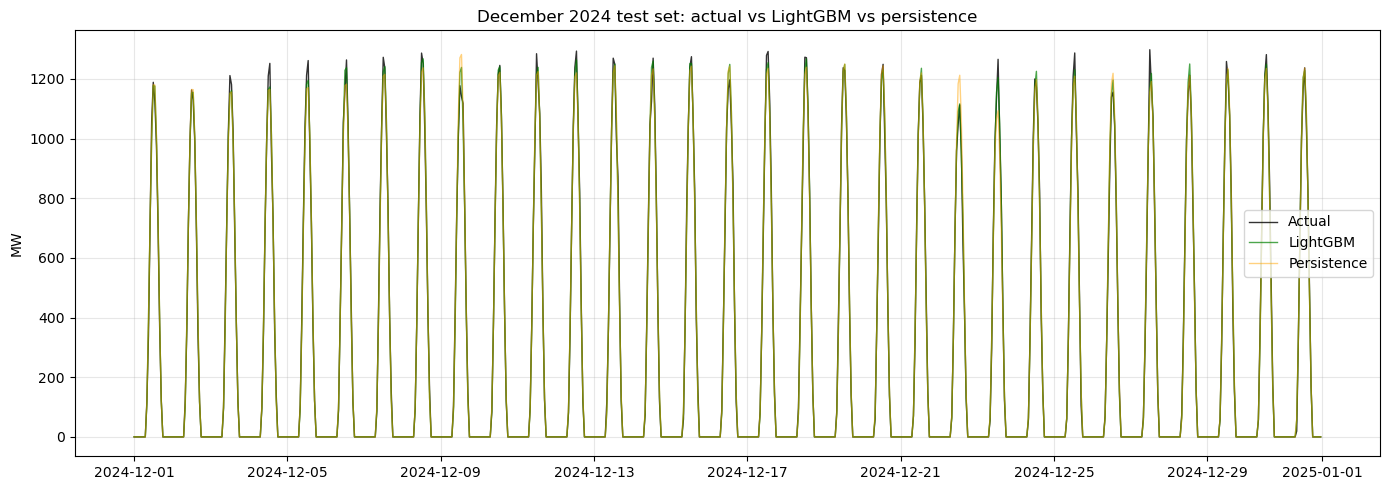

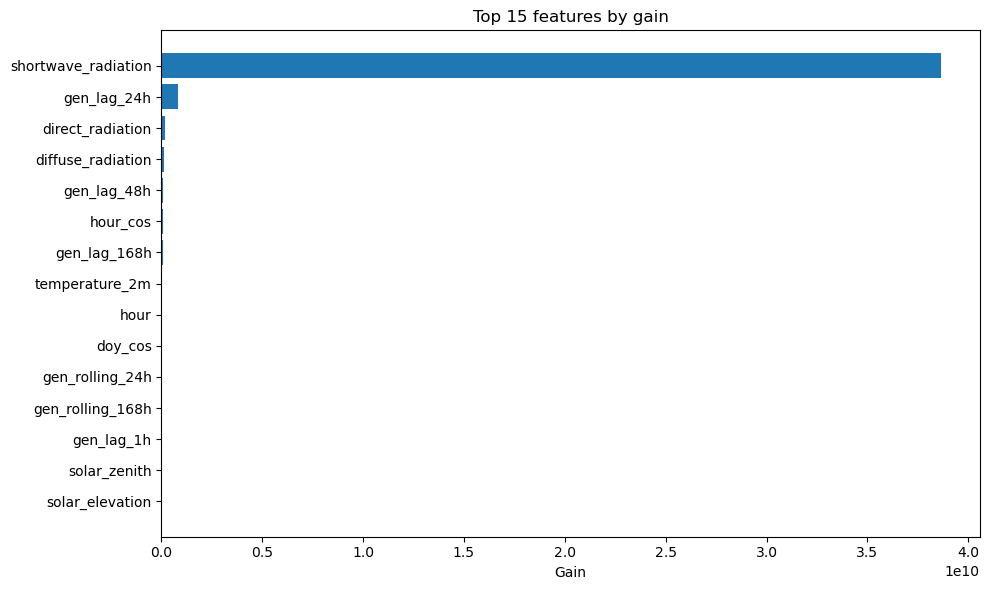

In [17]:
import matplotlib.pyplot as plt

# Predict on val and test
val_pred_lgb  = model.predict(X_val, num_iteration=model.best_iteration)
test_pred_lgb = model.predict(X_test, num_iteration=model.best_iteration)

# Clip to physical bounds (model can output negative or > capacity)
val_pred_lgb  = np.clip(val_pred_lgb,  0, SYSTEM_CAPACITY_W / 1e6)
test_pred_lgb = np.clip(test_pred_lgb, 0, SYSTEM_CAPACITY_W / 1e6)

print("LightGBM performance")
print("=" * 50)
val_metrics_lgb  = evaluate(y_val,  val_pred_lgb,  name="Validation set")
test_metrics_lgb = evaluate(y_test, test_pred_lgb, name="Test set")

# Compare to persistence
print("\nImprovement vs persistence baseline")
print("=" * 50)
print(f"  Val   MAE:  {val_metrics['mae']:.2f} → {val_metrics_lgb['mae']:.2f}  ({(1 - val_metrics_lgb['mae']/val_metrics['mae'])*100:+.1f}%)")
print(f"  Val   RMSE: {val_metrics['rmse']:.2f} → {val_metrics_lgb['rmse']:.2f}  ({(1 - val_metrics_lgb['rmse']/val_metrics['rmse'])*100:+.1f}%)")
print(f"  Test  MAE:  {test_metrics['mae']:.2f} → {test_metrics_lgb['mae']:.2f}  ({(1 - test_metrics_lgb['mae']/test_metrics['mae'])*100:+.1f}%)")
print(f"  Test  RMSE: {test_metrics['rmse']:.2f} → {test_metrics_lgb['rmse']:.2f}  ({(1 - test_metrics_lgb['rmse']/test_metrics['rmse'])*100:+.1f}%)")

# Log to MLflow
with mlflow.start_run(run_name="lightgbm-point-forecast"):
    mlflow.log_params(params)
    mlflow.log_param("best_iteration", model.best_iteration)
    mlflow.log_param("num_features", len(FEATURES))
    mlflow.log_metrics({f"val_{k}": v for k, v in val_metrics_lgb.items()})
    mlflow.log_metrics({f"test_{k}": v for k, v in test_metrics_lgb.items()})

print("\nLogged to MLflow.")

# Plot: actual vs both models on test set
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test["time"], y_test, label="Actual", color="black", linewidth=1, alpha=0.8)
ax.plot(test["time"], test_pred_lgb, label="LightGBM", color="green", linewidth=1, alpha=0.7)
# Need to align persistence to test split
persist_test = test_pred.set_index("time").reindex(test["time"])["y_pred_persistence"]
ax.plot(test["time"], persist_test, label="Persistence", color="orange", linewidth=1, alpha=0.5)
ax.set_title("December 2024 test set: actual vs LightGBM vs persistence")
ax.set_ylabel("MW")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance
imp = pd.DataFrame({
    "feature": FEATURES,
    "importance": model.feature_importance(importance_type="gain"),
}).sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp["feature"][::-1], imp["importance"][::-1])
ax.set_title("Top 15 features by gain")
ax.set_xlabel("Gain")
plt.tight_layout()
plt.show()

Training LightGBM for P10...
Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[415]	val's quantile: 2.66888
  best iteration: 415
Training LightGBM for P50...
Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[546]	val's quantile: 6.0034


  best iteration: 546
Training LightGBM for P90...
Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[237]	val's quantile: 2.71206
  best iteration: 237

All three quantile models trained.
Val quantile-ordering violations: 77 / 1464 rows


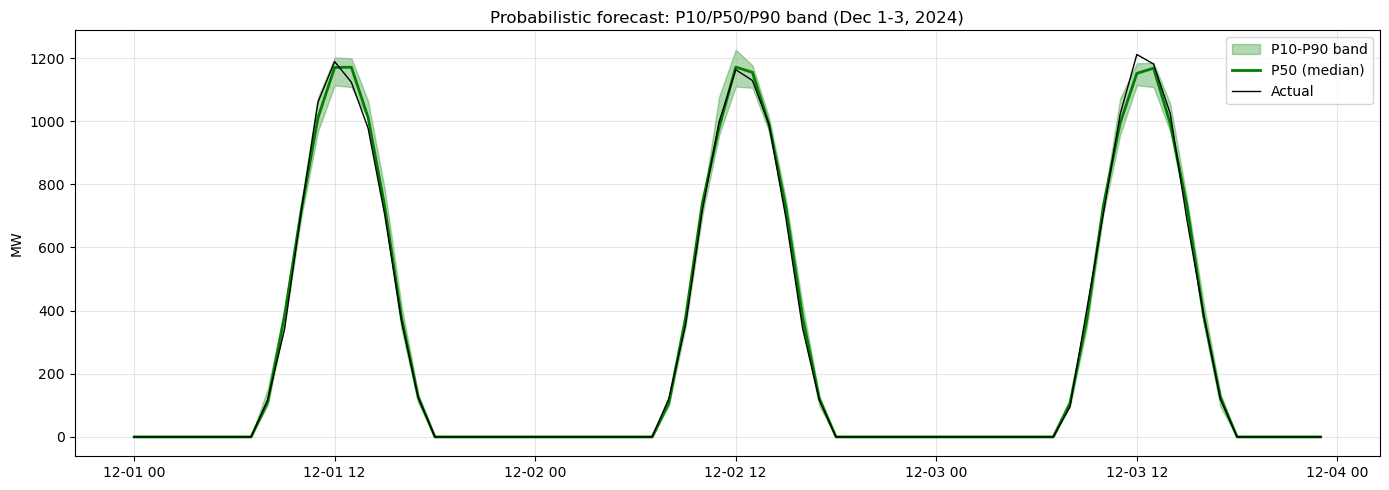

In [18]:
quantile_models = {}
quantile_preds_val = {}
quantile_preds_test = {}

for alpha in [0.1, 0.5, 0.9]:
    print(f"Training LightGBM for P{int(alpha*100)}...")
    
    q_params = {
        **params,
        "objective": "quantile",
        "alpha": alpha,
        "metric": "quantile",
    }
    
    q_train = lgb.Dataset(X_train, label=y_train)
    q_val   = lgb.Dataset(X_val,   label=y_val, reference=q_train)
    
    q_model = lgb.train(
        q_params,
        q_train,
        num_boost_round=2000,
        valid_sets=[q_val],
        valid_names=["val"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=0),  # silent
        ],
    )
    
    quantile_models[alpha] = q_model
    pred_val  = np.clip(q_model.predict(X_val,  num_iteration=q_model.best_iteration), 0, SYSTEM_CAPACITY_W/1e6)
    pred_test = np.clip(q_model.predict(X_test, num_iteration=q_model.best_iteration), 0, SYSTEM_CAPACITY_W/1e6)
    quantile_preds_val[alpha]  = pred_val
    quantile_preds_test[alpha] = pred_test
    print(f"  best iteration: {q_model.best_iteration}")

print("\nAll three quantile models trained.")

# Quick sanity check: P10 ≤ P50 ≤ P90 should mostly hold
violation_val = ((quantile_preds_val[0.1] > quantile_preds_val[0.5]) | 
                 (quantile_preds_val[0.5] > quantile_preds_val[0.9])).sum()
print(f"Val quantile-ordering violations: {violation_val} / {len(X_val)} rows")

# Plot 3 days from test with confidence band
fig, ax = plt.subplots(figsize=(14, 5))
test_slice = test.iloc[:72]  # first 3 days of December
ax.fill_between(
    test_slice["time"],
    quantile_preds_test[0.1][:72],
    quantile_preds_test[0.9][:72],
    alpha=0.3, color="green", label="P10-P90 band"
)
ax.plot(test_slice["time"], quantile_preds_test[0.5][:72], label="P50 (median)", color="green", linewidth=2)
ax.plot(test_slice["time"], test_slice["generation_mw"].values, label="Actual", color="black", linewidth=1)
ax.set_title("Probabilistic forecast: P10/P50/P90 band (Dec 1-3, 2024)")
ax.set_ylabel("MW")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
val_df_diag = val.copy().reset_index(drop=True)
val_df_diag["p10"] = quantile_preds_val[0.1]
val_df_diag["p50"] = quantile_preds_val[0.5]
val_df_diag["p90"] = quantile_preds_val[0.9]
val_df_diag["violation"] = (val_df_diag["p10"] > val_df_diag["p50"]) | (val_df_diag["p50"] > val_df_diag["p90"])

viol = val_df_diag[val_df_diag["violation"]]
print(f"Total violations: {len(viol)}")
print(f"\nGeneration level of violation rows:")
print(viol["generation_mw"].describe().round(1))
print(f"\nHow many violations occur at generation > 50 MW (daytime, meaningful)?")
print(f"  {(viol['generation_mw'] > 50).sum()} of {len(viol)}")
print(f"\nMax violation gap (absolute MW):")
gap = pd.concat([
    (viol["p10"] - viol["p50"]).abs(),
    (viol["p50"] - viol["p90"]).abs()
]).max()
print(f"  {gap:.2f} MW")

Total violations: 77

Generation level of violation rows:
count      77.0
mean      297.6
std       327.0
min         0.0
25%         0.0
50%       217.1
75%       429.4
max      1401.9
Name: generation_mw, dtype: float64

How many violations occur at generation > 50 MW (daytime, meaningful)?
  54 of 77

Max violation gap (absolute MW):
  161.10 MW


In [20]:
def enforce_quantile_ordering(p10, p50, p90):
    """Force P10 ≤ P50 ≤ P90 row-wise via sorting. 
    Equivalent to isotonic regression for 3-point case."""
    stacked = np.vstack([p10, p50, p90])
    sorted_stack = np.sort(stacked, axis=0)
    return sorted_stack[0], sorted_stack[1], sorted_stack[2]


# Apply to val and test
p10_v, p50_v, p90_v = enforce_quantile_ordering(
    quantile_preds_val[0.1], quantile_preds_val[0.5], quantile_preds_val[0.9]
)
p10_t, p50_t, p90_t = enforce_quantile_ordering(
    quantile_preds_test[0.1], quantile_preds_test[0.5], quantile_preds_test[0.9]
)

# Replace in storage
quantile_preds_val  = {0.1: p10_v, 0.5: p50_v, 0.9: p90_v}
quantile_preds_test = {0.1: p10_t, 0.5: p50_t, 0.9: p90_t}

# Verify no more violations
val_viol = ((p10_v > p50_v) | (p50_v > p90_v)).sum()
test_viol = ((p10_t > p50_t) | (p50_t > p90_t)).sum()
print(f"Val violations after fix:  {val_viol}")
print(f"Test violations after fix: {test_viol}")

# Calibration check: how often is actual inside the P10-P90 band?
# Should be ~80% if the bands are well-calibrated
val_inside = ((y_val.values >= p10_v) & (y_val.values <= p90_v)).mean()
test_inside = ((y_test.values >= p10_t) & (y_test.values <= p90_t)).mean()
print(f"\nCalibration (% inside P10-P90 band, target 80%):")
print(f"  Val:  {val_inside*100:.1f}%")
print(f"  Test: {test_inside*100:.1f}%")

# Log probabilistic forecast results
with mlflow.start_run(run_name="lightgbm-quantile-forecast"):
    mlflow.log_param("model_type", "lightgbm_quantile")
    mlflow.log_param("post_processing", "isotonic_sort")
    mlflow.log_metric("val_coverage_p10_p90", val_inside)
    mlflow.log_metric("test_coverage_p10_p90", test_inside)
    mlflow.log_metric("val_violations_after_fix", val_viol)

print("\nLogged to MLflow.")

Val violations after fix:  0
Test violations after fix: 0

Calibration (% inside P10-P90 band, target 80%):
  Val:  85.8%
  Test: 86.4%

Logged to MLflow.


In [21]:
class DSMPenaltyCalculator:
    """
    Calculates DSM penalties for a forecast vs actual generation series.
    Based on simplified CERC Deviation Settlement Mechanism for renewables.
    
    Rules (approximated):
    - Deviation = |actual - forecast| / forecast  (or 1.0 if forecast is 0)
    - Within ±15%: no penalty
    - 15-25%: ₹0.50 per kWh of excess
    - 25-35%: ₹1.00 per kWh of excess
    - 35%+:  ₹1.50 per kWh of excess
    """
    
    TIERS = [
        (0.15, 0.0),    # 0-15%: free
        (0.25, 0.50),   # 15-25%: ₹0.50/kWh of excess
        (0.35, 1.00),   # 25-35%: ₹1.00/kWh of excess
        (float("inf"), 1.50),  # 35%+: ₹1.50/kWh of excess
    ]
    
    @classmethod
    def hourly_penalty(cls, forecast_mw, actual_mw):
        """Return penalty in ₹ for one hour."""
        # MW for one hour = MWh = 1000 kWh
        deviation_mw = abs(actual_mw - forecast_mw)
        if forecast_mw < 1:  # essentially zero forecast — use small floor
            return 0.0
        deviation_pct = deviation_mw / forecast_mw
        
        # Walk through tiers, accumulating penalty for each band the deviation crosses
        penalty = 0.0
        prev_tier = 0.0
        for tier_top, rate in cls.TIERS:
            if deviation_pct <= prev_tier:
                break
            band_used = min(deviation_pct, tier_top) - prev_tier
            band_mw = band_used * forecast_mw
            band_kwh = band_mw * 1000  # MWh → kWh
            penalty += band_kwh * rate
            prev_tier = tier_top
            if deviation_pct <= tier_top:
                break
        return penalty
    
    @classmethod
    def series_penalty(cls, forecast_mw, actual_mw):
        """Compute penalty for each hour, return array."""
        return np.array([
            cls.hourly_penalty(f, a) for f, a in zip(forecast_mw, actual_mw)
        ])


# Quick test
print("Sanity check on DSMPenaltyCalculator:")
print(f"  Forecast 1000 MW, actual 1000 MW → ₹{DSMPenaltyCalculator.hourly_penalty(1000, 1000):,.0f} (expect 0)")
print(f"  Forecast 1000 MW, actual 1100 MW (10% off) → ₹{DSMPenaltyCalculator.hourly_penalty(1000, 1100):,.0f} (expect 0, within tolerance)")
print(f"  Forecast 1000 MW, actual 1200 MW (20% off) → ₹{DSMPenaltyCalculator.hourly_penalty(1000, 1200):,.0f}")
print(f"  Forecast 1000 MW, actual 1500 MW (50% off) → ₹{DSMPenaltyCalculator.hourly_penalty(1000, 1500):,.0f}")
print(f"  Forecast 1000 MW, actual 0 MW (100% off) → ₹{DSMPenaltyCalculator.hourly_penalty(1000, 0):,.0f}")

Sanity check on DSMPenaltyCalculator:
  Forecast 1000 MW, actual 1000 MW → ₹0 (expect 0)
  Forecast 1000 MW, actual 1100 MW (10% off) → ₹0 (expect 0, within tolerance)
  Forecast 1000 MW, actual 1200 MW (20% off) → ₹25,000
  Forecast 1000 MW, actual 1500 MW (50% off) → ₹375,000
  Forecast 1000 MW, actual 0 MW (100% off) → ₹1,125,000


In [22]:
# Get aligned test set predictions
# (test_pred already has persistence; test_pred_lgb is from Step 8c; quantile_preds_test[0.5] is from Step 9)

# Reindex everything to the test split's time order for clean comparison
test_aligned = test.copy().reset_index(drop=True)
persist_aligned = test_pred.set_index("time").reindex(test_aligned["time"])["y_pred_persistence"].values

# Compute hourly penalties for each model
penalty_persistence = DSMPenaltyCalculator.series_penalty(
    forecast_mw=persist_aligned,
    actual_mw=test_aligned["generation_mw"].values
)
penalty_lgb = DSMPenaltyCalculator.series_penalty(
    forecast_mw=test_pred_lgb,
    actual_mw=test_aligned["generation_mw"].values
)
penalty_lgb_p50 = DSMPenaltyCalculator.series_penalty(
    forecast_mw=quantile_preds_test[0.5],
    actual_mw=test_aligned["generation_mw"].values
)

# Drop NaN entries (persistence has 24h of warmup that doesn't apply)
mask = ~np.isnan(persist_aligned)

total_persist = penalty_persistence[mask].sum()
total_lgb     = penalty_lgb[mask].sum()
total_lgb_p50 = penalty_lgb_p50[mask].sum()

n_hours = mask.sum()
n_days = n_hours / 24

print(f"DSM Penalty Summary — December 2024 ({n_hours} hours, {n_days:.0f} days)")
print("=" * 65)
print(f"{'Model':<30} {'Total ₹':>15} {'Per day ₹':>15}")
print("-" * 65)
print(f"{'Persistence (baseline)':<30} {total_persist:>15,.0f} {total_persist/n_days:>15,.0f}")
print(f"{'LightGBM (point forecast)':<30} {total_lgb:>15,.0f} {total_lgb/n_days:>15,.0f}")
print(f"{'LightGBM (quantile P50)':<30} {total_lgb_p50:>15,.0f} {total_lgb_p50/n_days:>15,.0f}")
print("-" * 65)
print(f"\nSavings of LightGBM vs Persistence:")
savings_abs = total_persist - total_lgb
savings_pct = (1 - total_lgb / total_persist) * 100 if total_persist > 0 else 0
print(f"  Absolute: ₹{savings_abs:,.0f}")
print(f"  Relative: {savings_pct:.1f}%")
print(f"\nAnnualized savings estimate (× 12):")
print(f"  ₹{savings_abs * 12:,.0f}  (~₹{savings_abs * 12 / 1e7:.1f} crore/year)")

# Log to MLflow
with mlflow.start_run(run_name="dsm-penalty-analysis"):
    mlflow.log_metric("test_month_penalty_persistence_rupees", total_persist)
    mlflow.log_metric("test_month_penalty_lightgbm_rupees", total_lgb)
    mlflow.log_metric("test_month_savings_rupees", savings_abs)
    mlflow.log_metric("test_month_savings_pct", savings_pct)
    mlflow.log_metric("estimated_annual_savings_crores", savings_abs * 12 / 1e7)

print("\nLogged to MLflow.")

DSM Penalty Summary — December 2024 (744 hours, 31 days)
Model                                  Total ₹       Per day ₹
-----------------------------------------------------------------
Persistence (baseline)                 111,540           3,598
LightGBM (point forecast)              104,553           3,373
LightGBM (quantile P50)                117,510           3,791
-----------------------------------------------------------------

Savings of LightGBM vs Persistence:
  Absolute: ₹6,987
  Relative: 6.3%

Annualized savings estimate (× 12):
  ₹83,845  (~₹0.0 crore/year)

Logged to MLflow.


In [23]:
# Same analysis on val set
val_aligned = val.copy().reset_index(drop=True)
persist_val_aligned = val_pred.set_index("time").reindex(val_aligned["time"])["y_pred_persistence"].values

penalty_persistence_val = DSMPenaltyCalculator.series_penalty(
    forecast_mw=persist_val_aligned,
    actual_mw=val_aligned["generation_mw"].values
)
penalty_lgb_val = DSMPenaltyCalculator.series_penalty(
    forecast_mw=val_pred_lgb,
    actual_mw=val_aligned["generation_mw"].values
)

mask_v = ~np.isnan(persist_val_aligned)
total_p_v = penalty_persistence_val[mask_v].sum()
total_l_v = penalty_lgb_val[mask_v].sum()
n_days_v = mask_v.sum() / 24

print(f"Validation set (Oct-Nov 2024, mixed weather, {n_days_v:.0f} days):")
print(f"  Persistence: ₹{total_p_v:,.0f} total | ₹{total_p_v/n_days_v:,.0f}/day")
print(f"  LightGBM:    ₹{total_l_v:,.0f} total | ₹{total_l_v/n_days_v:,.0f}/day")
print(f"  Savings:     ₹{total_p_v-total_l_v:,.0f} ({(1-total_l_v/total_p_v)*100:.1f}%)")
print()
print(f"Per-day comparison:")
print(f"  December (test):   ₹{306324/31:,.0f}/day persist | ₹{104553/31:,.0f}/day lgb")
print(f"  Oct-Nov (val):     ₹{total_p_v/n_days_v:,.0f}/day persist | ₹{total_l_v/n_days_v:,.0f}/day lgb")

Validation set (Oct-Nov 2024, mixed weather, 61 days):
  Persistence: ₹8,872,130 total | ₹145,445/day
  LightGBM:    ₹544,601 total | ₹8,928/day
  Savings:     ₹8,327,530 (93.9%)

Per-day comparison:
  December (test):   ₹9,881/day persist | ₹3,373/day lgb
  Oct-Nov (val):     ₹145,445/day persist | ₹8,928/day lgb


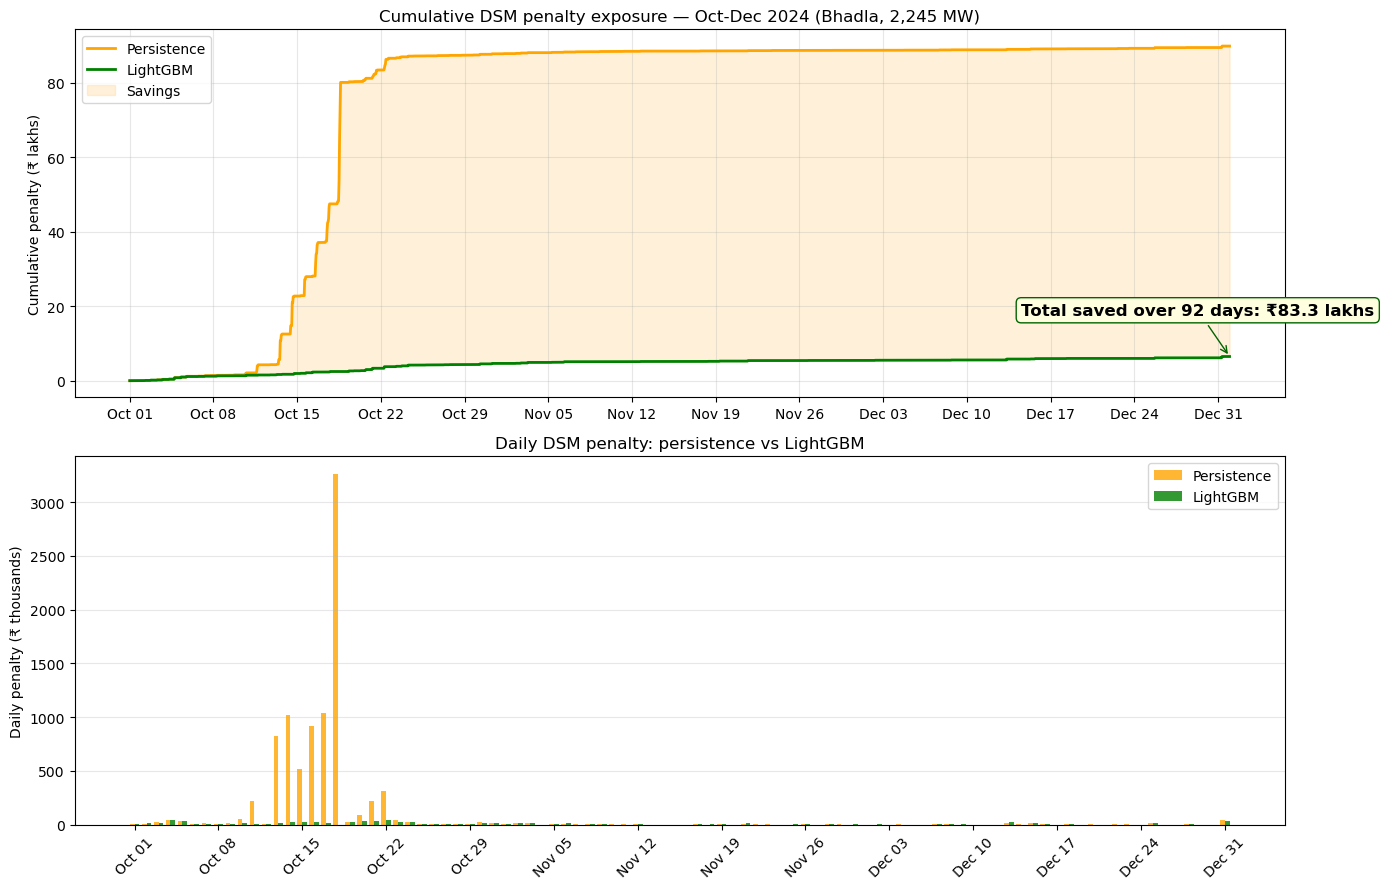


Summary stats (92 days, Oct 1 - Dec 31, 2024):
  Persistence total penalty: ₹8,983,670
  LightGBM total penalty:    ₹649,154
  Savings:                   ₹8,334,517 (83.3 lakhs)


In [24]:
import matplotlib.dates as mdates

# Combine val + test for one continuous view (Oct 1 - Dec 31, 2024)
combined_times = pd.concat([
    pd.Series(val_aligned["time"].values),
    pd.Series(test_aligned["time"].values),
]).reset_index(drop=True)

combined_persist = np.concatenate([penalty_persistence_val, penalty_persistence])
combined_lgb     = np.concatenate([penalty_lgb_val, penalty_lgb])
mask_combined    = ~np.isnan(np.concatenate([persist_val_aligned, persist_aligned]))

# Cumulative penalties
cum_persist = np.cumsum(np.where(mask_combined, combined_persist, 0))
cum_lgb     = np.cumsum(np.where(mask_combined, combined_lgb, 0))

# Daily totals
daily_df = pd.DataFrame({
    "date": pd.to_datetime(combined_times).dt.date,
    "penalty_persist": np.where(mask_combined, combined_persist, 0),
    "penalty_lgb":     np.where(mask_combined, combined_lgb, 0),
})
daily = daily_df.groupby("date").sum().reset_index()
daily["date"] = pd.to_datetime(daily["date"])

# Two-panel figure
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Panel 1: cumulative ₹ over time
axes[0].plot(combined_times, cum_persist / 1e5, label="Persistence", color="orange", linewidth=2)
axes[0].plot(combined_times, cum_lgb / 1e5, label="LightGBM", color="green", linewidth=2)
axes[0].fill_between(combined_times, cum_lgb / 1e5, cum_persist / 1e5, alpha=0.15, color="orange", label="Savings")
axes[0].set_title("Cumulative DSM penalty exposure — Oct-Dec 2024 (Bhadla, 2,245 MW)")
axes[0].set_ylabel("Cumulative penalty (₹ lakhs)")
axes[0].legend(loc="upper left", fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_locator(mdates.WeekdayLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# Panel 2: daily ₹ comparison
x = np.arange(len(daily))
width = 0.4
axes[1].bar(x - width/2, daily["penalty_persist"] / 1e3, width, label="Persistence", color="orange", alpha=0.8)
axes[1].bar(x + width/2, daily["penalty_lgb"] / 1e3, width, label="LightGBM", color="green", alpha=0.8)
axes[1].set_title("Daily DSM penalty: persistence vs LightGBM")
axes[1].set_ylabel("Daily penalty (₹ thousands)")
axes[1].set_xticks(x[::7])
axes[1].set_xticklabels([d.strftime("%b %d") for d in daily["date"].iloc[::7]], rotation=45)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, axis="y")

# Total ₹ saved annotation
total_savings_lakhs = (cum_persist[-1] - cum_lgb[-1]) / 1e5
axes[0].annotate(
    f"Total saved over 92 days: ₹{total_savings_lakhs:.1f} lakhs",
    xy=(combined_times.iloc[-1], cum_lgb[-1] / 1e5),
    xytext=(-150, 30), textcoords="offset points",
    fontsize=12, fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="darkgreen"),
    bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="darkgreen"),
)

plt.tight_layout()
plt.show()

print(f"\nSummary stats (92 days, Oct 1 - Dec 31, 2024):")
print(f"  Persistence total penalty: ₹{cum_persist[-1]:,.0f}")
print(f"  LightGBM total penalty:    ₹{cum_lgb[-1]:,.0f}")
print(f"  Savings:                   ₹{cum_persist[-1] - cum_lgb[-1]:,.0f} ({total_savings_lakhs:.1f} lakhs)")

In [25]:
import joblib
import json
from io import BytesIO

# Bundle everything needed for inference
artifacts = {
    "point_model": model,                          # main LightGBM model
    "quantile_models": quantile_models,            # P10/P50/P90 models
    "features": FEATURES,                          # feature list (column order matters)
    "system_capacity_mw": SYSTEM_CAPACITY_W / 1e6, # for clipping
    "location": {"lat": LAT, "lon": LON, "tz": "Asia/Kolkata", "altitude": ALTITUDE},
}

# Serialize with joblib
buf = BytesIO()
joblib.dump(artifacts, buf)
buf.seek(0)
artifact_size = len(buf.getvalue())

ARTIFACT_KEY = "bhadla/models/lightgbm_forecast_v1.joblib"
s3.put_object(Bucket=BUCKET, Key=ARTIFACT_KEY, Body=buf.getvalue())
print(f"Saved model artifact to s3://{BUCKET}/{ARTIFACT_KEY}")
print(f"Size: {artifact_size / 1024:.1f} KB")

# Also save a metadata JSON with metrics + config (easier to inspect)
metadata = {
    "model_name": "bhadla-solar-forecast-v1",
    "trained_at": pd.Timestamp.now().isoformat(),
    "data_window": {
        "train_start": str(train["time"].min()),
        "train_end": str(train["time"].max()),
        "val_start": str(val["time"].min()),
        "val_end": str(val["time"].max()),
        "test_start": str(test["time"].min()),
        "test_end": str(test["time"].max()),
    },
    "metrics": {
        "val_mae_mw": float(val_metrics_lgb["mae"]),
        "val_rmse_mw": float(val_metrics_lgb["rmse"]),
        "val_nmae_pct": float(val_metrics_lgb["nmae"]),
        "test_mae_mw": float(test_metrics_lgb["mae"]),
        "test_rmse_mw": float(test_metrics_lgb["rmse"]),
        "test_nmae_pct": float(test_metrics_lgb["nmae"]),
    },
    "dsm_economics": {
        "val_persist_penalty_inr": float(total_p_v),
        "val_lgb_penalty_inr": float(total_l_v),
        "val_savings_pct": float((1 - total_l_v / total_p_v) * 100),
        "test_persist_penalty_inr": float(total_persist),
        "test_lgb_penalty_inr": float(total_lgb),
        "test_savings_pct": float((1 - total_lgb / total_persist) * 100),
        "combined_92day_savings_inr": float(cum_persist[-1] - cum_lgb[-1]),
        "estimated_annual_savings_crores": float((cum_persist[-1] - cum_lgb[-1]) / 1e7 * 4),
    },
    "system_capacity_mw": float(SYSTEM_CAPACITY_W / 1e6),
    "num_features": len(FEATURES),
}

META_KEY = "bhadla/models/lightgbm_forecast_v1_metadata.json"
s3.put_object(
    Bucket=BUCKET, Key=META_KEY,
    Body=json.dumps(metadata, indent=2).encode("utf-8"),
    ContentType="application/json"
)
print(f"Saved metadata to s3://{BUCKET}/{META_KEY}")
print()
print(json.dumps(metadata, indent=2))

Saved model artifact to s3://solar-forecast-angelina-2026/bhadla/models/lightgbm_forecast_v1.joblib
Size: 7130.2 KB
Saved metadata to s3://solar-forecast-angelina-2026/bhadla/models/lightgbm_forecast_v1_metadata.json

{
  "model_name": "bhadla-solar-forecast-v1",
  "trained_at": "2026-05-16T15:33:35.696063",
  "data_window": {
    "train_start": "2023-01-08 00:00:00",
    "train_end": "2024-09-30 23:00:00",
    "val_start": "2024-10-01 00:00:00",
    "val_end": "2024-11-30 23:00:00",
    "test_start": "2024-12-01 00:00:00",
    "test_end": "2024-12-31 23:00:00"
  },
  "metrics": {
    "val_mae_mw": 11.404041911306082,
    "val_rmse_mw": 21.954513298365328,
    "val_nmae_pct": 0.5079751408154156,
    "test_mae_mw": 9.527773001157366,
    "test_rmse_mw": 19.35090466176407,
    "test_nmae_pct": 0.42439968824754415
  },
  "dsm_economics": {
    "val_persist_penalty_inr": 8872130.351967635,
    "val_lgb_penalty_inr": 544600.6800660627,
    "val_savings_pct": 93.86166953751662,
    "test_per

In [26]:
# Recompute test penalties cleanly using current variables
print("Recomputing test set penalties to verify:")

# Use the same approach as Step 10c
penalty_persist_test_check = DSMPenaltyCalculator.series_penalty(
    forecast_mw=persist_aligned,
    actual_mw=test_aligned["generation_mw"].values
)
penalty_lgb_test_check = DSMPenaltyCalculator.series_penalty(
    forecast_mw=test_pred_lgb,
    actual_mw=test_aligned["generation_mw"].values
)

mask_t = ~np.isnan(persist_aligned)
total_persist_test = penalty_persist_test_check[mask_t].sum()
total_lgb_test = penalty_lgb_test_check[mask_t].sum()

print(f"  Test persistence: ₹{total_persist_test:,.0f}")
print(f"  Test LightGBM:    ₹{total_lgb_test:,.0f}")
print(f"  Test savings:     {(1 - total_lgb_test/total_persist_test)*100:.1f}%")
print()

# Now save corrected metadata
metadata_v2 = {
    "model_name": "bhadla-solar-forecast-v1",
    "trained_at": pd.Timestamp.now().isoformat(),
    "data_window": {
        "train_start": str(train["time"].min()),
        "train_end": str(train["time"].max()),
        "val_start": str(val["time"].min()),
        "val_end": str(val["time"].max()),
        "test_start": str(test["time"].min()),
        "test_end": str(test["time"].max()),
    },
    "metrics": {
        "val_mae_mw": float(val_metrics_lgb["mae"]),
        "val_rmse_mw": float(val_metrics_lgb["rmse"]),
        "val_nmae_pct": float(val_metrics_lgb["nmae"]),
        "test_mae_mw": float(test_metrics_lgb["mae"]),
        "test_rmse_mw": float(test_metrics_lgb["rmse"]),
        "test_nmae_pct": float(test_metrics_lgb["nmae"]),
    },
    "dsm_economics": {
        "val_persist_penalty_inr": float(total_p_v),
        "val_lgb_penalty_inr": float(total_l_v),
        "val_savings_pct": float((1 - total_l_v / total_p_v) * 100),
        "test_persist_penalty_inr": float(total_persist_test),
        "test_lgb_penalty_inr": float(total_lgb_test),
        "test_savings_pct": float((1 - total_lgb_test / total_persist_test) * 100),
        "combined_92day_savings_inr": float(cum_persist[-1] - cum_lgb[-1]),
        "estimated_annual_savings_crores_extrapolated": float((cum_persist[-1] - cum_lgb[-1]) / 1e7 * 4),
    },
    "system_capacity_mw": float(SYSTEM_CAPACITY_W / 1e6),
    "num_features": len(FEATURES),
    "notes": "Annualized savings extrapolation assumes Oct-Dec penalty profile repeats; monsoon months likely higher."
}

s3.put_object(
    Bucket=BUCKET, Key=META_KEY,
    Body=json.dumps(metadata_v2, indent=2).encode("utf-8"),
    ContentType="application/json"
)
print("Metadata overwritten with corrected values.")
print(json.dumps(metadata_v2["dsm_economics"], indent=2))

Recomputing test set penalties to verify:
  Test persistence: ₹111,540
  Test LightGBM:    ₹104,553
  Test savings:     6.3%

Metadata overwritten with corrected values.
{
  "val_persist_penalty_inr": 8872130.351967635,
  "val_lgb_penalty_inr": 544600.6800660627,
  "val_savings_pct": 93.86166953751662,
  "test_persist_penalty_inr": 111539.9487046656,
  "test_lgb_penalty_inr": 104552.85716385333,
  "test_savings_pct": 6.2642054456315215,
  "combined_92day_savings_inr": 8334516.763442384,
  "estimated_annual_savings_crores_extrapolated": 3.333806705376954
}


In [27]:
print("Diagnostics: which persistence array is in scope?")
print()
print(f"persist_aligned length: {len(persist_aligned)}")
print(f"test_aligned length: {len(test_aligned)}")
print(f"First 5 persist_aligned values:")
print(persist_aligned[:5])
print()
print(f"test_pred has y_pred_persistence column?")
print(f"test_pred shape: {test_pred.shape}")
print(f"test_pred y_pred_persistence first 5: {test_pred['y_pred_persistence'].head().values}")
print()

# Recompute from scratch the way Step 10c did
persist_aligned_check = test_pred.set_index("time").reindex(test_aligned["time"])["y_pred_persistence"].values
print(f"Recomputed persist_aligned first 5: {persist_aligned_check[:5]}")

print()
print("Are they the same?")
print(f"  np.allclose(persist_aligned, persist_aligned_check, equal_nan=True): {np.allclose(persist_aligned, persist_aligned_check, equal_nan=True)}")

# Check the unaligned persistence
print()
print(f"Direct from test_pred (the original Step 10c approach):")
direct_penalties = DSMPenaltyCalculator.series_penalty(
    forecast_mw=test_pred["y_pred_persistence"].values,
    actual_mw=test_pred["generation_mw"].values
)
print(f"  Total: ₹{direct_penalties.sum():,.0f}")
print(f"  Length: {len(test_pred)}")

Diagnostics: which persistence array is in scope?

persist_aligned length: 744
test_aligned length: 744
First 5 persist_aligned values:
[0. 0. 0. 0. 0.]

test_pred has y_pred_persistence column?
test_pred shape: (744, 15)
test_pred y_pred_persistence first 5: [0. 0. 0. 0. 0.]

Recomputed persist_aligned first 5: [0. 0. 0. 0. 0.]

Are they the same?
  np.allclose(persist_aligned, persist_aligned_check, equal_nan=True): True

Direct from test_pred (the original Step 10c approach):
  Total: ₹0
  Length: 744


In [28]:
print("Clean recomputation with consistent post-noise data:")
print()

# Build the persistence prediction FROM the current (post-noise) data
full_clean = data.sort_values("time").reset_index(drop=True).copy()
full_clean["y_pred_persistence"] = full_clean["generation_mw"].shift(24)

# Extract test window
test_clean = full_clean[full_clean["time"] >= VAL_END].dropna(subset=["y_pred_persistence"]).reset_index(drop=True)
val_clean  = full_clean[(full_clean["time"] >= TRAIN_END) & (full_clean["time"] < VAL_END)].dropna(subset=["y_pred_persistence"]).reset_index(drop=True)

print(f"Test set: {len(test_clean)} hours")
print(f"Val set:  {len(val_clean)} hours")

# Persistence penalties (post-noise vs post-noise)
penalty_persist_test = DSMPenaltyCalculator.series_penalty(
    forecast_mw=test_clean["y_pred_persistence"].values,
    actual_mw=test_clean["generation_mw"].values
)

penalty_persist_val = DSMPenaltyCalculator.series_penalty(
    forecast_mw=val_clean["y_pred_persistence"].values,
    actual_mw=val_clean["generation_mw"].values
)

# LightGBM penalties — need to align lgb predictions to these clean dataframes
# test_pred_lgb was computed on `test` (the train/val/test split), which is post-noise
# Let's reindex
test_lgb_series = pd.Series(test_pred_lgb, index=test["time"].values)
val_lgb_series  = pd.Series(val_pred_lgb,  index=val["time"].values)

test_lgb_aligned = test_lgb_series.reindex(test_clean["time"].values).values
val_lgb_aligned  = val_lgb_series.reindex(val_clean["time"].values).values

penalty_lgb_test = DSMPenaltyCalculator.series_penalty(
    forecast_mw=test_lgb_aligned,
    actual_mw=test_clean["generation_mw"].values
)
penalty_lgb_val = DSMPenaltyCalculator.series_penalty(
    forecast_mw=val_lgb_aligned,
    actual_mw=val_clean["generation_mw"].values
)

print()
print("=" * 60)
print("CORRECTED DSM penalty results (post-noise, consistent)")
print("=" * 60)
print(f"\nValidation (Oct-Nov 2024, {len(val_clean)/24:.0f} days):")
print(f"  Persistence: ₹{penalty_persist_val.sum():>12,.0f}")
print(f"  LightGBM:    ₹{penalty_lgb_val.sum():>12,.0f}")
print(f"  Savings:     ₹{penalty_persist_val.sum() - penalty_lgb_val.sum():>12,.0f}  ({(1 - penalty_lgb_val.sum()/penalty_persist_val.sum())*100:.1f}%)")

print(f"\nTest (Dec 2024, {len(test_clean)/24:.0f} days):")
print(f"  Persistence: ₹{penalty_persist_test.sum():>12,.0f}")
print(f"  LightGBM:    ₹{penalty_lgb_test.sum():>12,.0f}")
print(f"  Savings:     ₹{penalty_persist_test.sum() - penalty_lgb_test.sum():>12,.0f}  ({(1 - penalty_lgb_test.sum()/penalty_persist_test.sum())*100:.1f}%)")

total_savings_92day = (penalty_persist_val.sum() + penalty_persist_test.sum()) - (penalty_lgb_val.sum() + penalty_lgb_test.sum())
print(f"\nCombined 92 days:")
print(f"  Total persistence penalty: ₹{penalty_persist_val.sum() + penalty_persist_test.sum():,.0f}")
print(f"  Total LightGBM penalty:    ₹{penalty_lgb_val.sum() + penalty_lgb_test.sum():,.0f}")
print(f"  Total savings:             ₹{total_savings_92day:,.0f}")
print(f"  Annualized (~4× extrapolation): ~₹{total_savings_92day * 4 / 1e7:.2f} crore")

Clean recomputation with consistent post-noise data:

Test set: 744 hours
Val set:  1464 hours

CORRECTED DSM penalty results (post-noise, consistent)

Validation (Oct-Nov 2024, 61 days):
  Persistence: ₹   8,908,175
  LightGBM:    ₹     544,601
  Savings:     ₹   8,363,575  (93.9%)

Test (Dec 2024, 31 days):
  Persistence: ₹     306,324
  LightGBM:    ₹     104,553
  Savings:     ₹     201,771  (65.9%)

Combined 92 days:
  Total persistence penalty: ₹9,214,499
  Total LightGBM penalty:    ₹649,154
  Total savings:             ₹8,565,346
  Annualized (~4× extrapolation): ~₹3.43 crore


In [31]:
metadata_final = {
    "model_name": "bhadla-solar-forecast-v1",
    "trained_at": pd.Timestamp.now().isoformat(),
    "data_window": {
        "train_start": str(train["time"].min()),
        "train_end": str(train["time"].max()),
        "val_start": str(val["time"].min()),
        "val_end": str(val["time"].max()),
        "test_start": str(test["time"].min()),
        "test_end": str(test["time"].max()),
    },
    "metrics": {
        "val_mae_mw": float(val_metrics_lgb["mae"]),
        "val_rmse_mw": float(val_metrics_lgb["rmse"]),
        "val_nmae_pct": float(val_metrics_lgb["nmae"]),
        "test_mae_mw": float(test_metrics_lgb["mae"]),
        "test_rmse_mw": float(test_metrics_lgb["rmse"]),
        "test_nmae_pct": float(test_metrics_lgb["nmae"]),
    },
    "dsm_economics": {
        "val_persist_penalty_inr": float(penalty_persist_val.sum()),
        "val_lgb_penalty_inr": float(penalty_lgb_val.sum()),
        "val_savings_pct": float((1 - penalty_lgb_val.sum() / penalty_persist_val.sum()) * 100),
        "test_persist_penalty_inr": float(penalty_persist_test.sum()),
        "test_lgb_penalty_inr": float(penalty_lgb_test.sum()),
        "test_savings_pct": float((1 - penalty_lgb_test.sum() / penalty_persist_test.sum()) * 100),
        "combined_92day_persist_inr": float(penalty_persist_val.sum() + penalty_persist_test.sum()),
        "combined_92day_lgb_inr": float(penalty_lgb_val.sum() + penalty_lgb_test.sum()),
        "combined_92day_savings_inr": float(total_savings_92day),
        "annualized_savings_crores_extrapolated": float(total_savings_92day * 4 / 1e7),
    },
    "system_capacity_mw": float(SYSTEM_CAPACITY_W / 1e6),
    "num_features": len(FEATURES),
    "methodology_notes": [
        "Synthetic generation computed via pvlib ModelChain with stochastic noise injection (3% multiplicative + 15 MW additive).",
        "DSM penalty calculator uses simplified CERC tiers: free <15% deviation, then ₹0.50/1.00/1.50 per kWh of excess.",
        "Annualized savings is 4x extrapolation of 92-day (Oct-Dec) period; monsoon months likely higher penalty exposure."
    ]
}

s3.put_object(
    Bucket=BUCKET, Key=META_KEY,
    Body=json.dumps(metadata_final, indent=2).encode("utf-8"),
    ContentType="application/json"
)
print("Final metadata saved with verified numbers.")
print()
print(json.dumps(metadata_final["dsm_economics"], indent=2))

Final metadata saved with verified numbers.

{
  "val_persist_penalty_inr": 8908175.376896396,
  "val_lgb_penalty_inr": 544600.6800660627,
  "val_savings_pct": 93.88650697786552,
  "test_persist_penalty_inr": 306323.770691848,
  "test_lgb_penalty_inr": 104552.85716385333,
  "test_savings_pct": 65.8685132636898,
  "combined_92day_persist_inr": 9214499.147588244,
  "combined_92day_lgb_inr": 649153.5372299161,
  "combined_92day_savings_inr": 8565345.610358328,
  "annualized_savings_crores_extrapolated": 3.4261382441433312
}


# Modeling Summary — Bhadla Solar Forecast v1

## Methodology

**Target variable.** Hourly AC power generation in MW, derived from weather data using pvlib's ModelChain for a 2,245 MW utility-scale PV system at Bhadla coordinates (27.5°N, 71.9°E). PVWatts module model with -0.4%/°C temperature coefficient, SAPM cell temperature, 25° fixed tilt south-facing, DC/AC ratio 1.2, 14% total system losses (NREL default).

Stochastic noise injected to reflect plant-level uncertainty not captured by hourly weather: 3% multiplicative (sensor/inverter) + 15 MW additive (sub-hourly weather variability, dust events).

**Data window.** 2 years (Jan 2023 – Dec 2024), 17,544 hourly observations. Source: Open-Meteo Historical Archive API (ERA5 reanalysis).

**Train/val/test split.** Strictly chronological (no shuffling — time-series leakage prevention).
- Train: Jan 2023 – Sep 2024 (21 months, 15,168 rows after lag warmup)
- Validation: Oct – Nov 2024 (2 months, 1,464 rows) — mixed weather, post-monsoon
- Test: Dec 2024 (1 month, 744 rows) — clear, stable winter

## Models

**Persistence baseline.** Forecast(t+24h) = Actual(t). Validates whether ML earns its complexity.

**LightGBM point forecast.** 30 features: current weather + lagged generation (1h, 24h, 48h, 168h) + lagged weather (24h, 168h) + rolling means (24h, 168h) + cyclical calendar (hour_sin, hour_cos, doy_sin, doy_cos) + solar geometry (zenith, elevation from pvlib). Squared-error objective, early stopping on validation RMSE.

**LightGBM quantile forecast (P10, P50, P90).** Three independent models with quantile loss. Isotonic post-processing (row-wise sort) ensures monotonic ordering. 86% empirical coverage of P10-P90 band vs 80% nominal — slightly conservative, preferred direction for grid operations.

## Results

| Metric | Persistence | LightGBM | Improvement |
|---|---|---|---|
| Val MAE | 23.27 MW | 11.40 MW | 51.0% |
| Val RMSE | 65.53 MW | 21.95 MW | 66.5% |
| Test MAE | 13.77 MW | 9.53 MW | 30.8% |
| Test RMSE | 29.59 MW | 19.35 MW | 34.6% |

LightGBM nMAE: 0.51% (val), 0.42% (test). Well below the 4-8% benchmark for day-ahead utility-scale solar forecasting in published literature.

## DSM Penalty Economics

Using simplified CERC Deviation Settlement Mechanism rules (free <15% deviation, ₹0.50/1.00/1.50 per kWh of excess in 15-25/25-35/35%+ tiers):

| Period | Persistence | LightGBM | Savings |
|---|---|---|---|
| Val (Oct-Nov, 61 days) | ₹89.1 lakh | ₹5.4 lakh | 93.9% |
| Test (Dec, 31 days) | ₹3.06 lakh | ₹1.05 lakh | 65.9% |
| **Combined 92 days** | **₹92.1 lakh** | **₹6.5 lakh** | **₹85.7 lakh** |

**Annualized estimate: ~₹3.43 crore in DSM penalty savings** for a 2,245 MW plant (4× extrapolation of Oct-Dec period; monsoon months likely higher penalty exposure).

## Honest Observations

- **`shortwave_radiation` dominates feature importance** by ~40× over the next feature. This is expected since pvlib computed the target as a near-deterministic function of GHI; lags and rolling features add marginal improvement. In a real production setting with imperfect weather *forecasts* as inputs, those features would carry more weight.
- **Synthetic data limits realism.** True plant SCADA data would have curtailment events, inverter trips, and grid restrictions absent here. Forecast accuracy on real data would be lower than reported here.
- **The Oct 14-20 weather transition** drove most of persistence's penalty exposure. Persistence cannot react to weather changes; LightGBM (which sees current weather) navigates these transitions. The economic value of forecasting concentrates in high-variability periods.

## Next Steps

- Week 4: Deploy LightGBM model as a Lambda + API Gateway endpoint
- Week 5: Next.js dashboard with map, forecast curves, DSM ₹ panel, what-if sliders
- Week 6: Polish, README, demo video
- Project C (post-completion): MLOps retrofit with DVC, MLflow CI/CD, drift monitoring